In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('residential_housing.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,Utilities,LandSlope,Condition2,...,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,NaN,RL,65.0,8450.0,Pave,Grvl,AllPub,Gtl,Norm,...,0.0,0.0,0.0,Ex,0.0,2.0,NaN,WD,Normal,208500.0
1,2.0,20.0,RL,80.0,9600.0,Pave,Grvl,AllPub,Gtl,Norm,...,0.0,0.0,0.0,Ex,0.0,5.0,2007.0,WD,Normal,181500.0
2,3.0,60.0,RL,68.0,11250.0,Pave,Grvl,AllPub,Gtl,Norm,...,0.0,0.0,0.0,Ex,0.0,9.0,2008.0,WD,Normal,223500.0
3,4.0,70.0,RL,60.0,9550.0,Pave,Grvl,AllPub,Gtl,Norm,...,0.0,0.0,0.0,Ex,0.0,2.0,2006.0,WD,Abnorml,140000.0
4,5.0,60.0,RL,84.0,14260.0,Pave,Grvl,AllPub,Gtl,Norm,...,0.0,NaN,0.0,Ex,0.0,12.0,2008.0,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456.0,60.0,RL,62.0,7917.0,Pave,Pave,AllPub,Gtl,Norm,...,0.0,0.0,NaN,Gd,0.0,NaN,2007.0,WD,Normal,175000.0
1456,1457.0,20.0,RL,85.0,13175.0,Pave,Pave,AllPub,Gtl,Norm,...,0.0,0.0,NaN,Gd,0.0,2.0,2010.0,WD,Normal,210000.0
1457,1458.0,70.0,RL,66.0,NaN,Pave,Pave,AllPub,Gtl,Norm,...,0.0,0.0,0.0,Gd,2500.0,5.0,2010.0,WD,Normal,266500.0
1458,1459.0,20.0,RL,68.0,9717.0,Pave,Pave,AllPub,Gtl,Norm,...,0.0,0.0,0.0,Gd,0.0,4.0,2010.0,WD,Normal,142125.0


In [4]:
missing_per_column = df.isna().sum()
total_missing = missing_per_column.sum()

print(missing_per_column)
print("Total missing values:", total_missing)

Id                 0
MSSubClass       163
MSZoning           0
LotFrontage      397
LotArea          154
Street             0
Alley              0
Utilities          0
LandSlope          0
Condition2         0
BldgType           0
OverallQual      100
OverallCond      159
YearBuilt        120
YearRemodAdd     117
RoofMatl           0
MasVnrArea       139
ExterQual          0
Foundation         0
BsmtQual           0
BsmtCond           0
BsmtExposure       0
BsmtFinSF1       101
BsmtFinSF2       117
BsmtUnfSF         68
TotalBsmtSF      102
Heating            0
CentralAir         0
Electrical         0
1stFlrSF         119
2ndFlrSF          52
LowQualFinSF      69
GrLivArea        107
BsmtFullBath     140
BsmtHalfBath      96
FullBath         139
HalfBath          67
BedroomAbvGr      53
KitchenAbvGr     119
TotRmsAbvGrd     124
Fireplaces        70
FireplaceQu        0
GarageType         0
GarageYrBlt      150
GarageCars       142
GarageArea        91
GarageQual         0
WoodDeckSF   

Number of tuples with specific missing values:
1    295
2    384
3    331
4    188
5     90
6     30
7     10
8      7
9      1
Name: count, dtype: int64


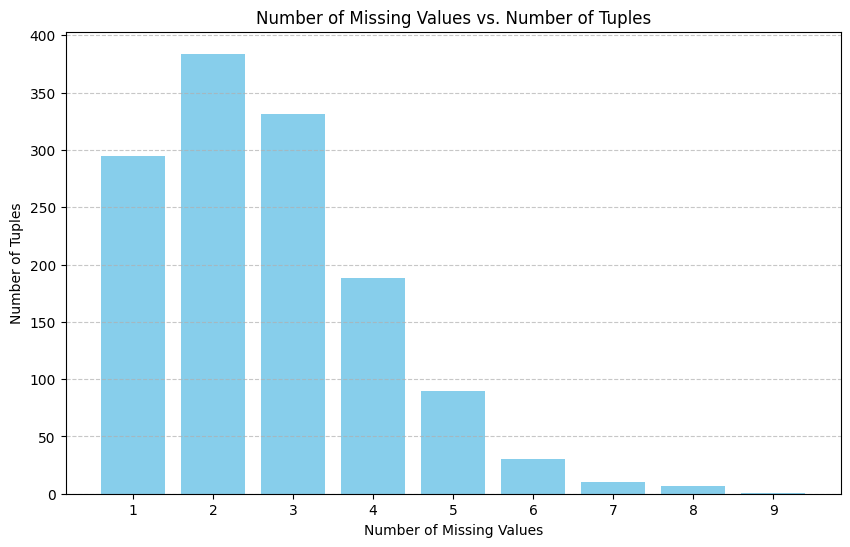

Number of tuples with >=50% of attributes missing: 15
After dropping tuples with >=50% missing values, the dataset has 1445 rows.
After dropping tuples with missing 'SalePrice' attribute, the dataset has 1410 rows.
Cleaned dataset saved as 'residential_housing_updated.csv'.


In [3]:
missing_counts = df.isnull().sum(axis=1)

missing_value_distribution = missing_counts.value_counts().sort_index().loc[1:9]

print("Number of tuples with specific missing values:")
print(missing_value_distribution)


plt.figure(figsize=(10, 6))
plt.bar(missing_value_distribution.index, missing_value_distribution.values, color='skyblue')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Tuples')
plt.title('Number of Missing Values vs. Number of Tuples')
plt.xticks(range(missing_value_distribution.index.min(), missing_value_distribution.index.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


threshold = len(df.columns) / 2

tuples_with_high_missing = (missing_counts >= threshold).sum()
print(f"Number of tuples with >=50% of attributes missing: {tuples_with_high_missing}")


df_cleaned = df[missing_counts < threshold]
print(f"After dropping tuples with >=50% missing values, the dataset has {len(df_cleaned)} rows.")


df_target_cleaned = df_cleaned.dropna(subset=['SalePrice'])
print(f"After dropping tuples with missing 'SalePrice' attribute, the dataset has {len(df_target_cleaned)} rows.")

df_target_cleaned.to_csv('residential_housing_updated.csv', index=False)
print("Cleaned dataset saved as 'residential_housing_updated.csv'.")
